# Long Short-Term Memory (LSTM) - TensorFlow / Keras

In [4]:
import os
import random
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# -----------------------------
# Reproducibility: Set seeds
# -----------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)

print(f"TensorFlow version: {tf.__version__}")

# -----------------------------
# Generate synthetic dataset
# -----------------------------
samples, seq_len, features = 1400, 30, 3
X = np.random.normal(size=(samples, seq_len, features)).astype("float32")

signal = (
    X[:, -10:, 0].mean(axis=1) +
    0.5 * X[:, :10, 1].mean(axis=1)
)
y = (signal > 0.05).astype("int64")

# Train/test split
X_train, X_test = X[:1000], X[1000:]
y_train, y_test = y[:1000], y[1000:]

# -----------------------------
# Define LSTM model
# -----------------------------
model = keras.Sequential([
    layers.Input(shape=(seq_len, features)),
    layers.LSTM(32),
    layers.Dropout(0.2),
    layers.Dense(2, activation="softmax"),
])

model.compile(
    optimizer=keras.optimizers.AdamW(1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

# -----------------------------
# Train model
# -----------------------------
model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=64
)

TensorFlow version: 2.20.0


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                   │ (None, 32)             │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │            66 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,674 (18.26 KB)

 Trainable params: 4,674 (18.26 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step - accuracy: 0.5550 - loss: 0.6841 - val_accuracy: 0.6825 - val_loss: 0.6448
Epoch 2/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7420 - loss: 0.6046 - val_accuracy: 0.7425 - val_loss: 0.5719
Epoch 3/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.7660 - loss: 0.5311 - val_accuracy: 0.7575 - val_loss: 0.5080
Epoch 4/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8050 - loss: 0.4724 - val_accuracy: 0.7900 - val_loss: 0.4517
Epoch 5/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.8130 - loss: 0.4299 - val_accuracy: 0.8050 - val_loss: 0.4223
Epoch 6/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.8210 - loss: 0.4004 - val_accuracy: 0.8125 - val_loss: 0.3900
Epoch 7/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8510 - loss: 0.3610 - val_accuracy: 0.8400 - val_loss: 0.3492
Epoch 8/10
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8700 - loss: 0.3212 - val_accuracy: 0.8550 - v

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_3 (LSTM)                   │ (None, 50, 64)         │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_4 (LSTM)                   │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 49,985 (195.25 KB)

 Trainable params: 49,985 (195.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 7s 128ms/step - loss: 0.1797 - val_loss: 0.0162
Epoch 2/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 54ms/step - loss: 0.0064 - val_loss: 0.0022
Epoch 3/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 0.0010 - val_loss: 3.3623e-04
Epoch 4/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step - loss: 3.9890e-04 - val_loss: 2.2382e-04
Epoch 5/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 2.5056e-04 - val_loss: 1.7403e-04
Epoch 6/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 53ms/step - loss: 1.8349e-04 - val_loss: 1.3928e-04
Epoch 7/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 88ms/step - loss: 1.3420e-04 - val_loss: 1.0550e-04
Epoch 8/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - loss: 9.6173e-05 - val_loss: 7.5948e-05
Epoch 9/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 76ms/step - loss: 6.6036e-05 - val_loss: 5.3181e-05
Epoch 10/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - loss: 4.3683e-05 - val_loss: 3.4592e-05
Epoch 11/30
22/22 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step - loss: 2.7119e-05 - val_loss: 1.991

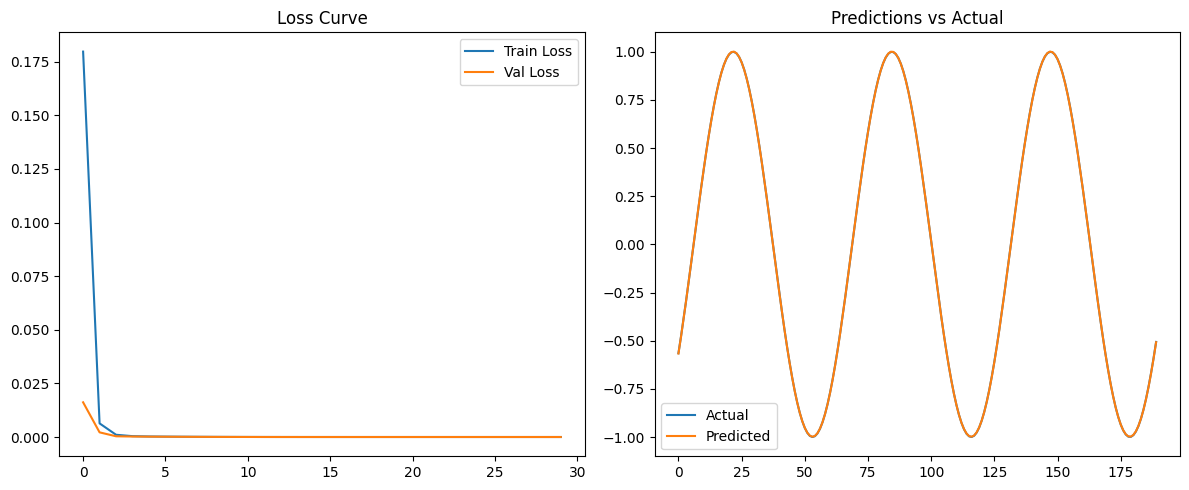

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Input

# -----------------------------
# Create Sine Wave Dataset
# -----------------------------
def create_sine_data(seq_length=50, num_samples=1000):
    x = np.linspace(0, 100, num_samples)
    y = np.sin(x)

    sequences, targets = [], []
    for i in range(len(y) - seq_length):
        sequences.append(y[i:i+seq_length])
        targets.append(y[i+seq_length])

    return np.array(sequences), np.array(targets)

SEQ_LEN = 50
X, y = create_sine_data(SEQ_LEN)

X = X[..., np.newaxis]
y = y[..., np.newaxis]

train_size = int(0.8 * len(X))
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

# -----------------------------
# ✅ Correct LSTM Model
# -----------------------------
model = Sequential([
    Input(shape=(SEQ_LEN, 1)),
    LSTM(64, return_sequences=True),
    LSTM(64),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

# -----------------------------
# Train
# -----------------------------
history = model.fit(
    X_train, y_train,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# -----------------------------
# Predict
# -----------------------------
predictions = model.predict(X_test)

# -----------------------------
# Visualize
# -----------------------------
plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss Curve")

plt.subplot(1,2,2)
plt.plot(y_test.squeeze(), label='Actual')
plt.plot(predictions.squeeze(), label='Predicted')
plt.legend()
plt.title("Predictions vs Actual")

plt.tight_layout()
plt.show()